# 🧠 06c — TabNet SSL Runner (Google Colab T4 GPU)

**Pipeline:** Financial Recommendation System — Step 06c Experimental Variant  
**Model:** Self-Supervised TabNet (PyTorch) + Multi-Task Fine-Tuning  
**Target:** Break the 0.797 AUC ceiling on `IncomeInvestment`  

---

### ⚡ Before You Start
1. **Runtime → Change runtime type → T4 GPU**  
2. Upload your project files to Google Drive (or clone from GitHub)  
3. Set `PROJECT_PATH` in Cell 2 to the folder containing the script files  
4. Run cells **in order** (Shift+Enter or Runtime → Run all)

---

In [11]:
# ============================================================
# CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive

drive.mount('/content/drive', force_remount=False)
print('✅ Google Drive mounted at /content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted at /content/drive


In [12]:
# ============================================================
# CELL 2 — Configura il percorso del progetto
# ============================================================
# Modifica PROJECT_PATH con il percorso esatto dove hai caricato
# i file su Drive (06c_pytorch_tabnet_ssl.py, utils.py, Dataset2_Needs.xls).
#
# Gli output (CSV, PNG, ZIP) verranno salvati in:
#   PROJECT_PATH/Output/06c_tabnet_ssl/
# i.e. DENTRO la cartella Fintech, non fuori.

import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

# ⬇️  MODIFICA QUI se i tuoi file sono in un percorso diverso
PROJECT_PATH = "/content/drive/MyDrive/Fintech_proj2"

# Imposta la cartella di output esplicita (dentro PROJECT_PATH).
# Lo script legge TABNET_SSL_OUTPUT_DIR per sovrascrivere il path
# relativo di default, che non è corretto quando i file sono in
# una directory piatta su Drive (non nella struttura Main_files/).
os.environ['TABNET_SSL_OUTPUT_DIR'] = os.path.join(PROJECT_PATH, 'Output', '06c_tabnet_ssl')

if os.path.exists(PROJECT_PATH):
    os.chdir(PROJECT_PATH)
    print(f'✅ Working dir : {os.getcwd()}')
    print(f'✅ Output  dir : {os.environ["TABNET_SSL_OUTPUT_DIR"]}')
    print(f'📂 Files found : {os.listdir(".")}')
    for f in ['06c_pytorch_tabnet_ssl.py', 'utils.py', 'Dataset2_Needs.xls']:
        status = '✔️ ' if f in os.listdir('.') else '⚠️  MISSING'
        print(f'   {status}  {f}')
else:
    print(f'❌ ERRORE: {PROJECT_PATH} non esiste. Controlla il percorso.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Working dir : /content/drive/MyDrive/Fintech_proj2
✅ Output  dir : /content/drive/MyDrive/Fintech_proj2/Output/06c_tabnet_ssl
📂 Files found : ['Dataset2_Needs.xls', 'utils.py', '06c_pytorch_tabnet_ssl.py']
   ✔️   06c_pytorch_tabnet_ssl.py
   ✔️   utils.py
   ✔️   Dataset2_Needs.xls


In [13]:
# ============================================================
# CELL 3 — Install Dependencies
# ============================================================
# Colab already has torch, pandas, numpy, scikit-learn, matplotlib, seaborn.
# We only need to install pytorch-tabnet and tabulate (not pre-installed).

print('📦 Installing missing dependencies...')

!pip install pytorch-tabnet --quiet
!pip install optuna --quiet
!pip install tabulate --quiet
!pip install openpyxl xlrd --quiet   # required for pandas to read .xls files

import torch
if torch.cuda.is_available():
    print(f'\n✅ GPU available: {torch.cuda.get_device_name(0)}')
    print(f'   CUDA version : {torch.version.cuda}')
    print(f'   VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('\n⚠️  No GPU detected — running on CPU (slower but correct).')
    print('   → Go to Runtime → Change runtime type → GPU → T4')

print('\n✅ All dependencies ready.')

📦 Installing missing dependencies...



✅ GPU available: Tesla T4
   CUDA version : 12.8
   VRAM         : 15.6 GB

✅ All dependencies ready.


In [14]:
# ============================================================
# CELL 4 — Execute the TabNet SSL Pipeline
# ============================================================
# Runs 06c_pytorch_tabnet_ssl.py from PROJECT_PATH.
#
# Output goes to:  PROJECT_PATH/Output/06c_tabnet_ssl/
#   06c_results.csv
#   06c_tabnet_ssl_model.zip
#   06c_Global_Feature_Importance.png
#   06c_Local_Saliency_Map.png
#
# Expected runtime on T4 GPU: ~6-15 minutes total
#   Phase 1 SSL  : ~3-5 min   (200 epochs max, early stopping)
#   Phase 2 Fine : ~4-8 min   (300 epochs max, early stopping)

import time
start = time.time()

print('🚀 Launching 06c_pytorch_tabnet_ssl.py ...')
print('=' * 70)

!python 06c_pytorch_tabnet_ssl.py

elapsed = time.time() - start
print('=' * 70)
print(f'⏱️  Total wall-clock time: {elapsed/60:.1f} minutes')

🚀 Launching 06c_pytorch_tabnet_ssl.py ...
🔒 PyTorch Deterministic Seed locked (42).
STEP 06c: SELF-SUPERVISED TABNET (PYTORCH) — MULTI-TASK LEARNING
 -> Device : CUDA (Tesla T4)
 -> Output : /content/drive/MyDrive/Fintech_proj2/Output/06c_tabnet_ssl

[1] Loading and preparing data...
 -> Train : 4000 | Test: 1000
 -> Features: 15 | Tasks: 2

[2] Running Optuna (15 trials)...
Stop training because you reached max_epochs = 70 with best_epoch = 69 and best_val_0_unsup_loss_numpy = 0.48427000641822815

Early stopping occurred at epoch 34 with best_epoch = 19 and best_val_0_auc = 0.76196
Stop training because you reached max_epochs = 70 with best_epoch = 69 and best_val_0_unsup_loss_numpy = 0.45831000804901123

Early stopping occurred at epoch 59 with best_epoch = 44 and best_val_0_auc = 0.8088

Early stopping occurred at epoch 49 with best_epoch = 34 and best_val_0_unsup_loss_numpy = 0.5751299858093262

Early stopping occurred at epoch 23 with best_epoch = 8 and best_val_0_auc = 0.75399

🔥

📁 Output directory: /content/drive/MyDrive/Fintech_proj2/Output/06c_tabnet_ssl
   Files: ['06c_tabnet_ssl_model.zip', '06c_results.csv', '06c_Global_Feature_Importance.png', '06c_Local_Saliency_Map.png']

📊 Results Table:


,Algorithm,Target,Test ROC-AUC,F1 Macro,F1 Class-1,Precision Class-1,Recall Class-1
0,TabNet SSL + MTL (PyTorch),AccumulationInvestment,0.8412,0.7768,0.7603,0.8523,0.6862
1,TabNet SSL + MTL (PyTorch),IncomeInvestment,0.8218,0.7903,0.7347,0.8157,0.6683



📈 Global Feature Importance:


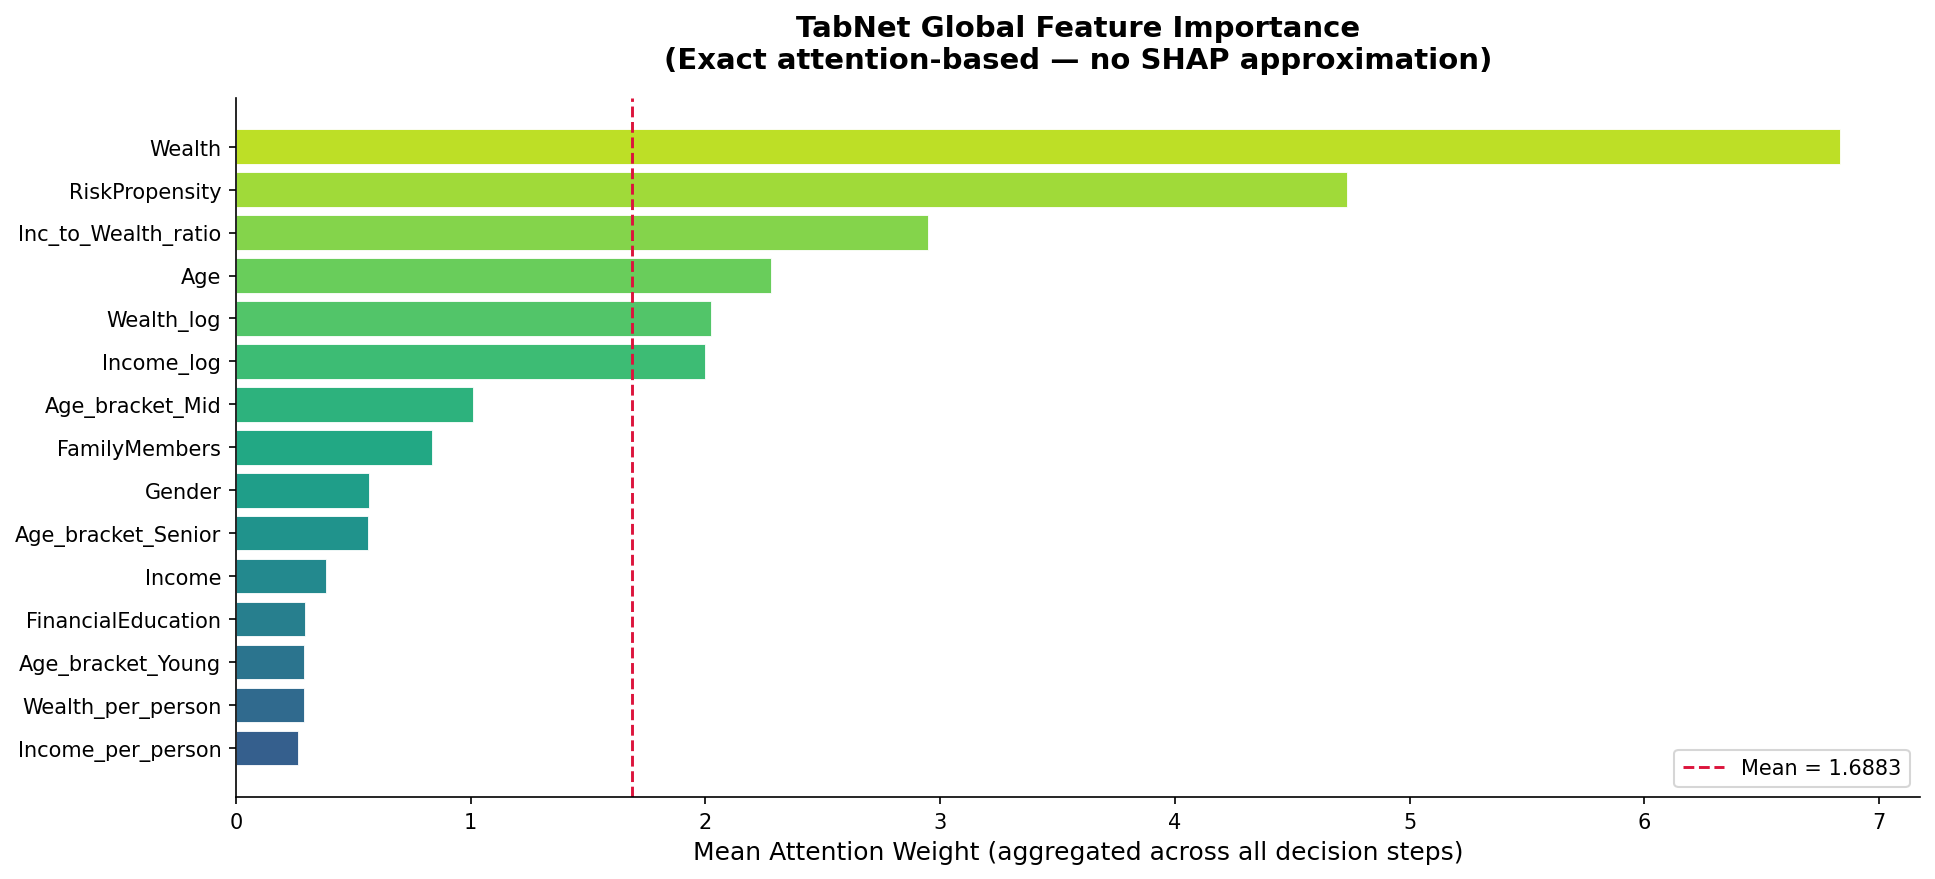


🗺️ Local Saliency Map (first 50 test clients):


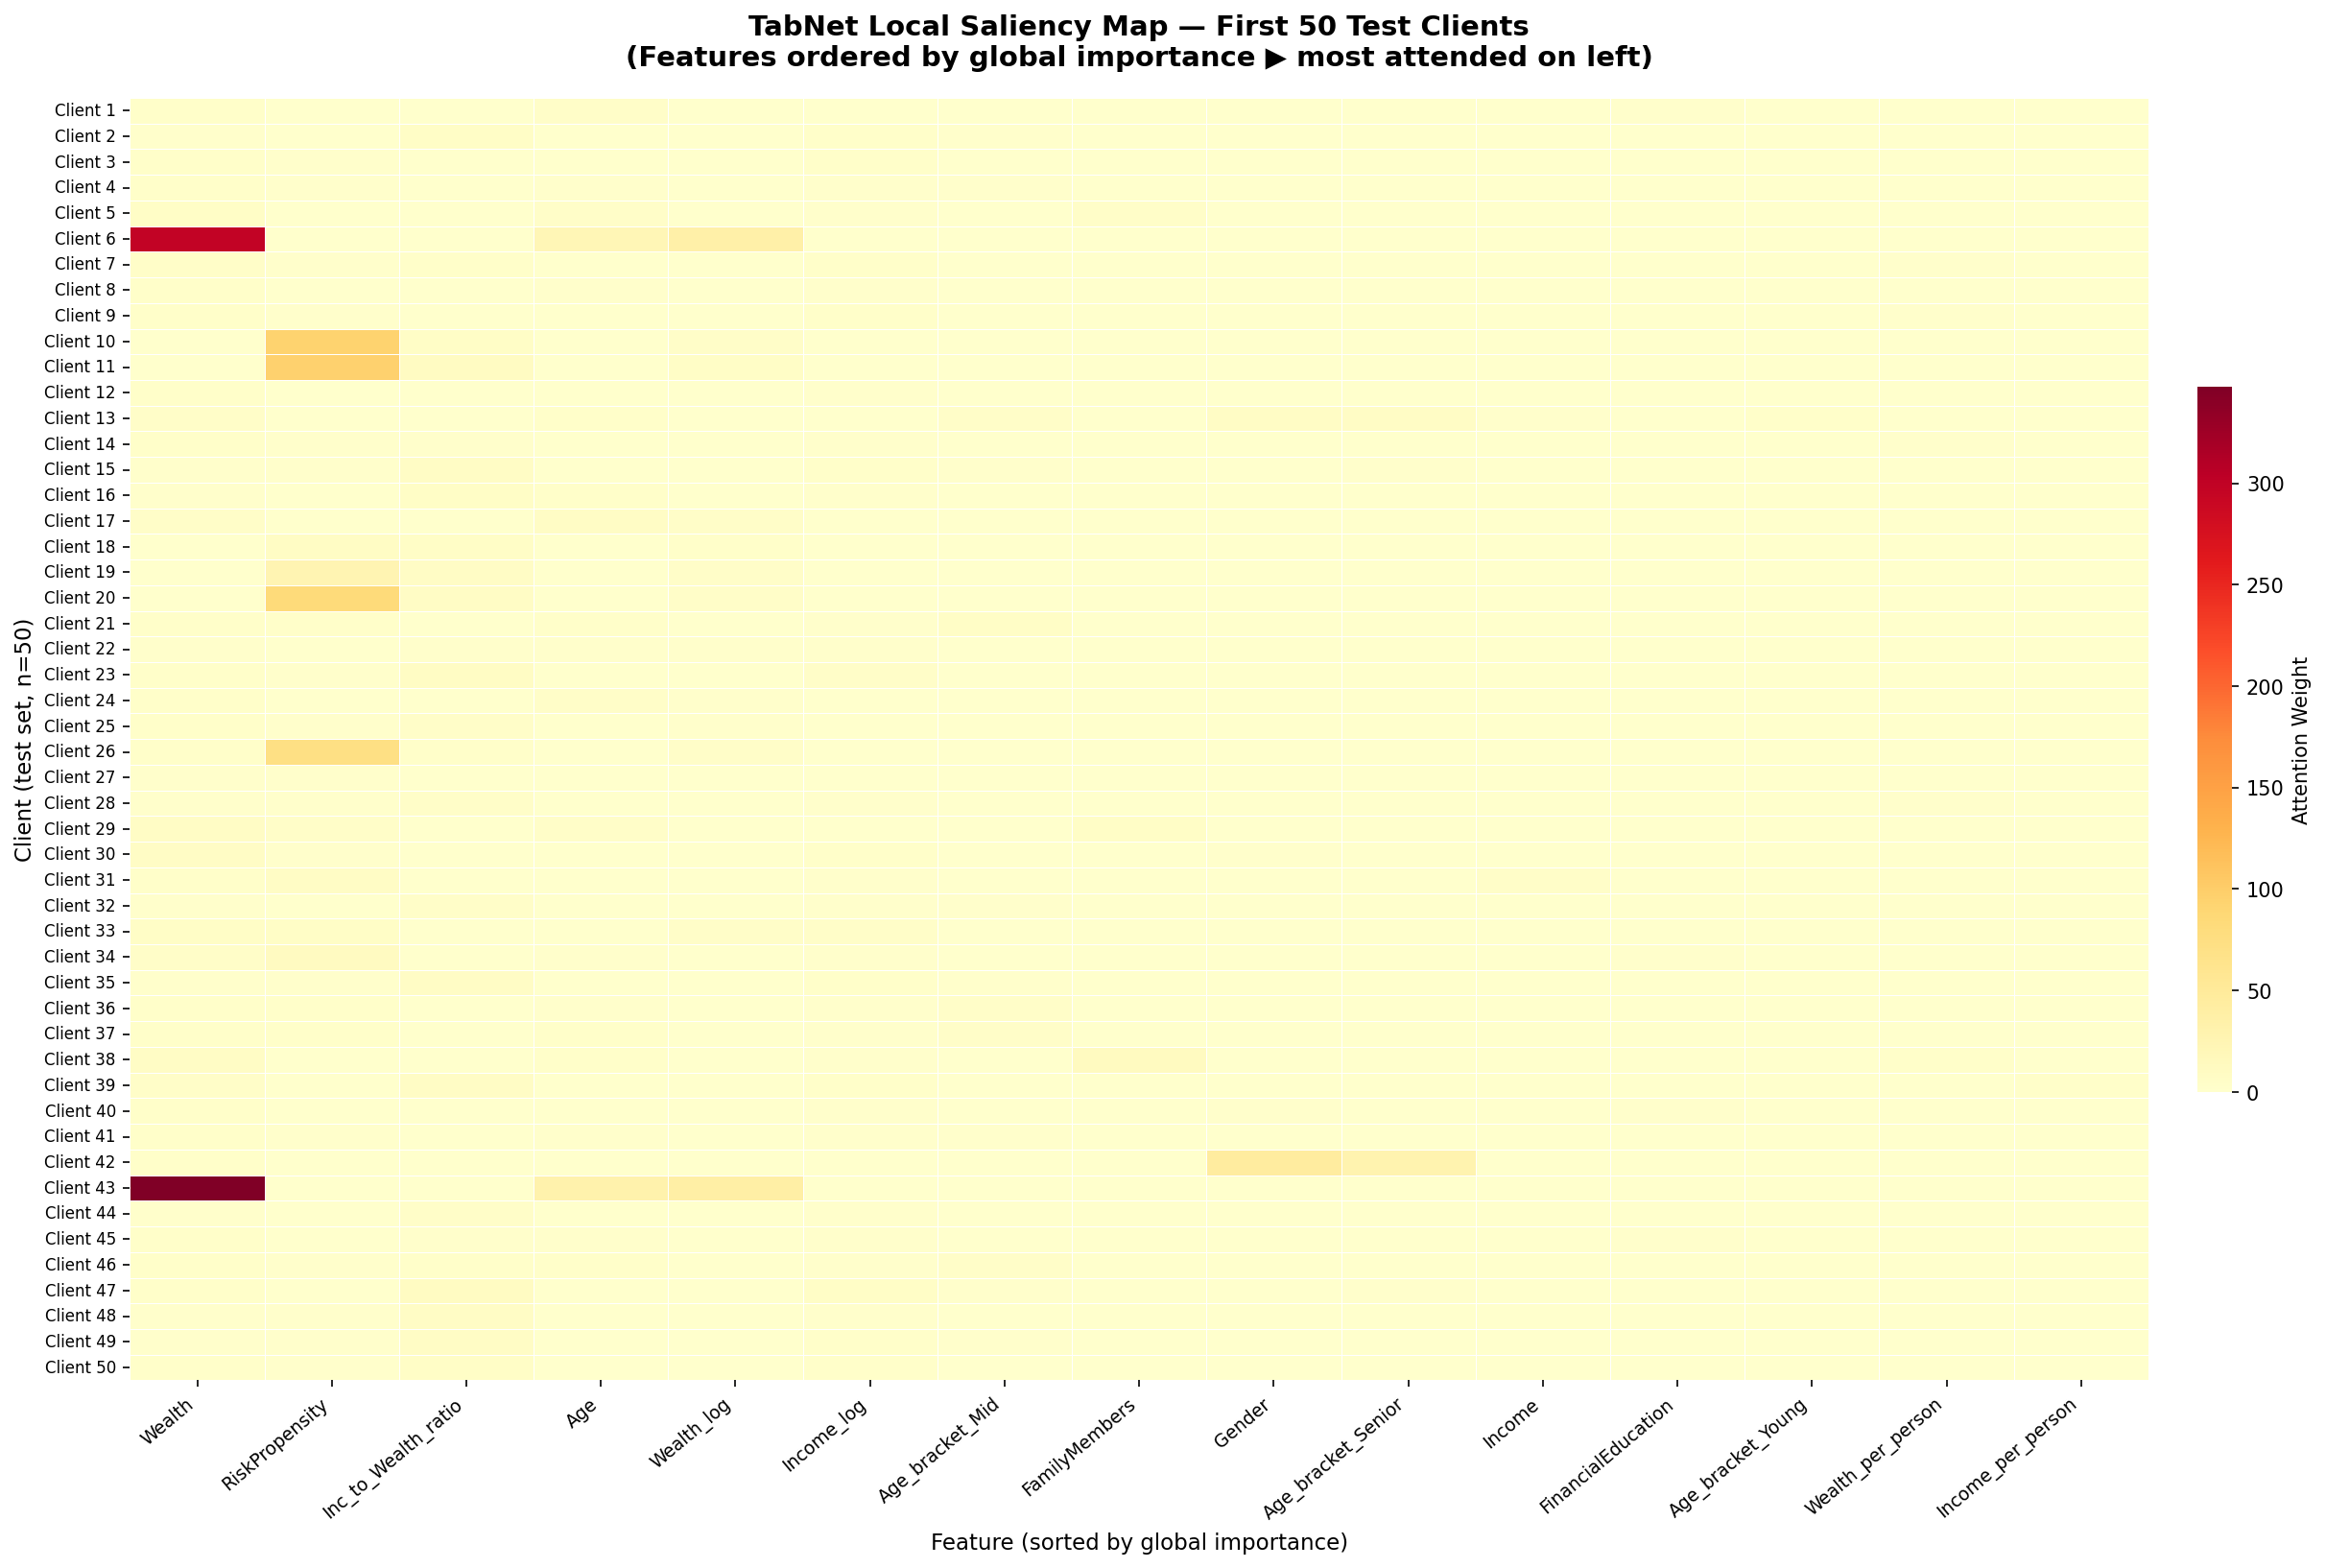

In [15]:
# ============================================================
# CELL 5 — Preview Results & Visualizations
# ============================================================

import os
import pandas as pd
from IPython.display import Image, display

OUTPUT_DIR = os.environ.get('TABNET_SSL_OUTPUT_DIR')

print(f'📁 Output directory: {OUTPUT_DIR}')
print(f'   Files: {os.listdir(OUTPUT_DIR)}')

print('\n📊 Results Table:')
df = pd.read_csv(os.path.join(OUTPUT_DIR, '06c_results.csv'))
display(df)

print('\n📈 Global Feature Importance:')
display(Image(os.path.join(OUTPUT_DIR, '06c_Global_Feature_Importance.png'), width=900))

print('\n🗺️ Local Saliency Map (first 50 test clients):')
display(Image(os.path.join(OUTPUT_DIR, '06c_Local_Saliency_Map.png'), width=1100))